In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [4]:
def get_data():

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

    data = pd.read_csv(url, sep=";")
    data.head()

    data["bool_quality"] = data["quality"].apply(lambda x: 0 if x <= 5 else 1)

    # convert from pandas to tensor
    X = torch.tensor(data.drop(["quality", "bool_quality"], axis=1).values, dtype=torch.float32)
    y = torch.tensor(data["bool_quality"].values, dtype=torch.float32).unsqueeze(1) # unsqueeze to make it a column vector

    # split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=17)

    # normalize the input data with StandardScaler (we don't need to normalize the output data since it's already binary)
    scaler_X = StandardScaler()
    X_train = torch.tensor(scaler_X.fit_transform(X_train), dtype=torch.float32)
    X_test = torch.tensor(scaler_X.transform(X_test), dtype=torch.float32)

    # create dataloaders
    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)

    batch_size = 32
    test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)

    return train_dl, test_dl

In [5]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(11, 16)
        self.fc2 = nn.Linear(16, 32)
        self.fc3 = nn.Linear(32, 32)
        self.fc4 = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x
    
def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    batch_acc = []
    batch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Binary classification: threshold at 0 (equivalent to sigmoid > 0.5)
        preds = (output > 0).float()
        batch_acc_item = (preds == y_batch).float().mean().item()
        batch_acc.append(batch_acc_item)
        batch_loss.append(loss.item())
        
    return np.mean(batch_acc), np.mean(batch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                # Binary classification: threshold at 0 (equivalent to sigmoid > 0.5)
                preds = (output > 0).float()
                test_acc[epoch] = (preds == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses


In [6]:
learning_rate = 0.01
epochs = 600
train_dl, test_dl = get_data()
loss_fn = nn.BCEWithLogitsLoss()

model_xavier = SimpleNN()
optimizer = torch.optim.SGD(model_xavier.parameters(), lr=learning_rate)

for p in model_xavier.named_parameters():
    if "weight" in p[0]:
        nn.init.xavier_normal_(p[1].data)

train_acc_x, test_acc_x, losses_x = train_model(model_xavier, train_dl, test_dl, optimizer, loss_fn, epochs)

In [34]:
model_kaiming = SimpleNN()
optimizer = torch.optim.SGD(model_kaiming.parameters(), lr=learning_rate)

for p in model_kaiming.named_parameters():
    if "weight" in p[0]:
        nn.init.kaiming_uniform_(p[1].data, nonlinearity="relu")
        # nonlinearity="relu" is important to tell the function that we are using ReLU 
        # activation functions in our model, so it can initialize the weights accordingly

train_acc_k, test_acc_k, losses_k = train_model(model_kaiming, train_dl, test_dl, optimizer, loss_fn, epochs)

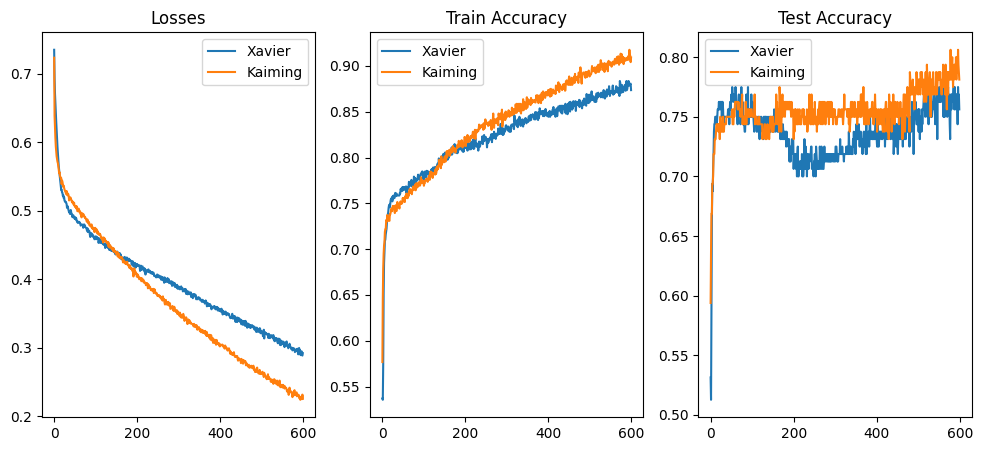

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].plot(losses_x, label="Xavier")
ax[0].plot(losses_k, label="Kaiming")
ax[0].set_title("Losses")
ax[0].legend()

ax[1].plot(train_acc_x, label="Xavier")
ax[1].plot(train_acc_k, label="Kaiming")
ax[1].set_title("Train Accuracy")
ax[1].legend()

ax[2].plot(test_acc_x, label="Xavier")
ax[2].plot(test_acc_k, label="Kaiming")
ax[2].set_title("Test Accuracy")
ax[2].legend()

# kaiming does better during training, but for testing they are pretty similar. so this could mean a little bit
# of overfitting with kaiming, but it's not a huge difference, so it could also be just random variation.

In [ ]:
num_experiments = 10

results = np.zeros((num_experiments, 3, 2)) 

for i in range(num_experiments):
    model_xavier = SimpleNN()
    optimizer = torch.optim.SGD(model_xavier.parameters(), lr=learning_rate)

    for p in model_xavier.named_parameters():
        if "weight" in p[0]:
            nn.init.xavier_normal_(p[1].data)

    train_acc_x, test_acc_x, losses_x = train_model(model_xavier, train_dl, test_dl, optimizer, loss_fn, epochs)

    model_kaiming = SimpleNN()
    optimizer = torch.optim.SGD(model_kaiming.parameters(), lr=learning_rate)

    for p in model_kaiming.named_parameters():
        if "weight" in p[0]:
            nn.init.kaiming_uniform_(p[1].data, nonlinearity="relu")

    train_acc_k, test_acc_k, losses_k = train_model(model_kaiming, train_dl, test_dl, optimizer, loss_fn, epochs)
    
    # for results we will store the mean of the last 5 epochs:
    results[i] = [[train_acc_x[-5:].mean(), train_acc_k[-5:].mean()], [test_acc_x[-5:].mean(), test_acc_k[-5:].mean()], [losses_x[-5:].mean(), losses_k[-5:].mean()]]

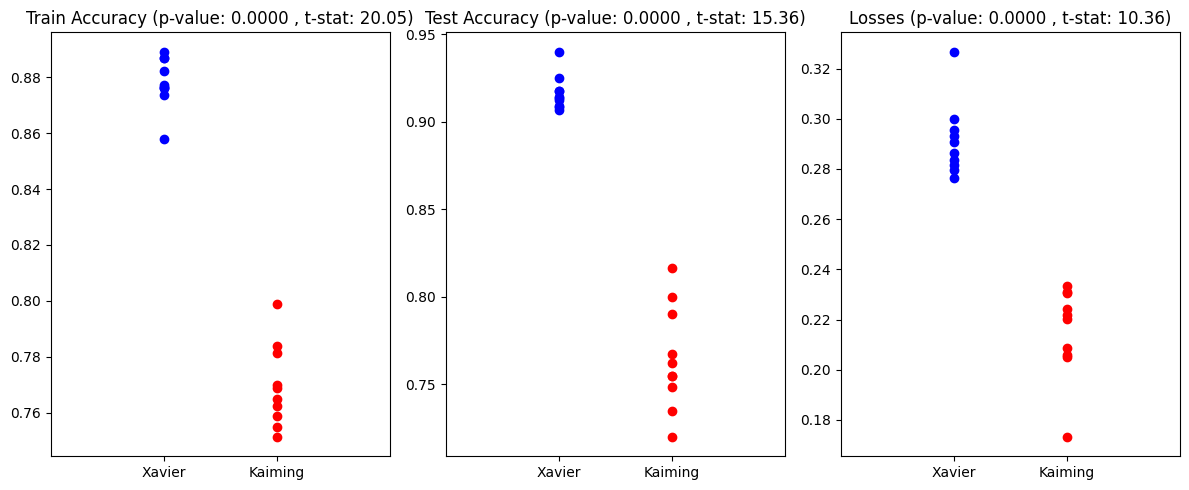

In [39]:
# plot the results

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

metrics = ["Train Accuracy", "Test Accuracy", "Losses"]

for i in range(3):
    ax[i].plot(np.zeros(num_experiments), results[:, i, 0], "bo", label="Xavier")
    ax[i].plot(np.ones(num_experiments), results[:, i, 1], "ro", label="Kaiming")

    # run a t-test to see if the difference between the two groups is statistically significant
    t_stat, p_value = stats.ttest_ind(results[:, i, 0], results[:, i, 1])
    title = f"{metrics[i]} (p-value: {p_value:.4f} , t-stat: {t_stat:.2f})"
    ax[i].set_title(title)

    ax[i].set_xticks([0, 1])
    ax[i].set_xticklabels(["Xavier", "Kaiming"])
    ax[i].set_xlim(-1, 2)

plt.tight_layout()
plt.show()

# Freezing weights

In [ ]:
model = SimpleNN()

# switch off all layers except the first one to see the effect of the weight 
# initialization on the first layer only. We will use requires_grad = False to freeze 
# the layers we don't want to train
for p in model.named_parameters():
    if "fc1" not in p[0]:
        p[1].requires_grad = False

for p in model.named_parameters():
    print("Requires grad:", p[1].requires_grad, " - ", p[0])

Requires grad: True  -  fc1.weight
Requires grad: True  -  fc1.bias
Requires grad: False  -  fc2.weight
Requires grad: False  -  fc2.bias
Requires grad: False  -  fc3.weight
Requires grad: False  -  fc3.bias
Requires grad: False  -  fc4.weight
Requires grad: False  -  fc4.bias


In [13]:
# another example freezing weights, but we will apply it during the training loop

def train_model_frozen(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        if epoch < (epochs//2):
            for p in model.named_parameters():
                if "fc1" not in p[0]: # only train one layer for the first half of the epochs
                    p[1].requires_grad = False
        else:
            for p in model.named_parameters():
                p[1].requires_grad = True # train all layers for the second half of the epochs

        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                # Binary classification: threshold at 0 (equivalent to sigmoid > 0.5)
                preds = (output > 0).float()
                test_acc[epoch] = (preds == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

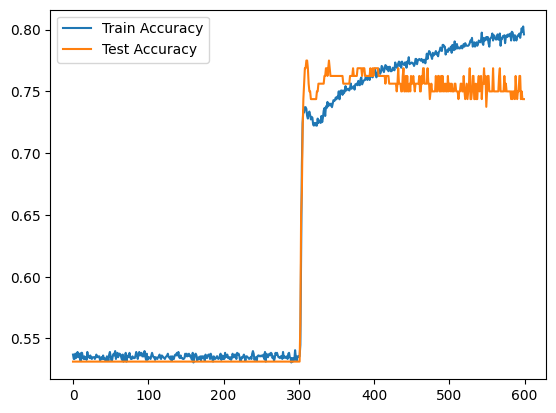

In [14]:
model = SimpleNN()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_acc_frozen, test_acc_frozen, losses_frozen = train_model_frozen(model, train_dl, test_dl, optimizer, loss_fn, epochs)

plt.plot(train_acc_frozen, label="Train Accuracy")
plt.plot(test_acc_frozen, label="Test Accuracy")
plt.legend()
plt.show()

# we appreciate that with one layer the model is able to learn something, but it doesn't do as well as when we train all the layers. 
# when we activate all the layers we can observe a big jump in the accuracy, which means that the model was able to learn much better 
# with all the layers being trained.

# Evaluate weights changes

In [24]:
# another example freezing weights, but we will apply it during the training loop

def train_model_weights(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    weight_change = np.zeros((epochs, 4))
    weight_conds = np.zeros((epochs, 4))

    for epoch in range(epochs):

        # store the weights for each layer
        preW = []
        for p in model.named_parameters():
            if "weight" in p[0]:
                preW.append(p[1].data.clone()) # clone to avoid modifying the original tensor

        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                # Binary classification: threshold at 0 (equivalent to sigmoid > 0.5)
                preds = (output > 0).float()
                test_acc[epoch] = (preds == y_batch).float().mean().item()

        # store the weight changes and conditions for each layer
        for (i, p) in enumerate(model.named_parameters()):
            if "weight" in p[0]:
                weight_change[epoch, int(i/2)] = np.linalg.norm(p[1].data - preW[int(i/2)]).item() # L2 norm of the weight change
                weight_conds[epoch, int(i/2)] = np.linalg.cond(p[1].data) # condition number of the weights (how close they are to being singular)
                
    return train_acc, test_acc, losses, weight_change, weight_conds, preW

In [27]:
epochs = 60
model = SimpleNN()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_acc, test_acc, losses, weight_change, weight_conds, preW = train_model_weights(model, train_dl, test_dl, optimizer, loss_fn, epochs)

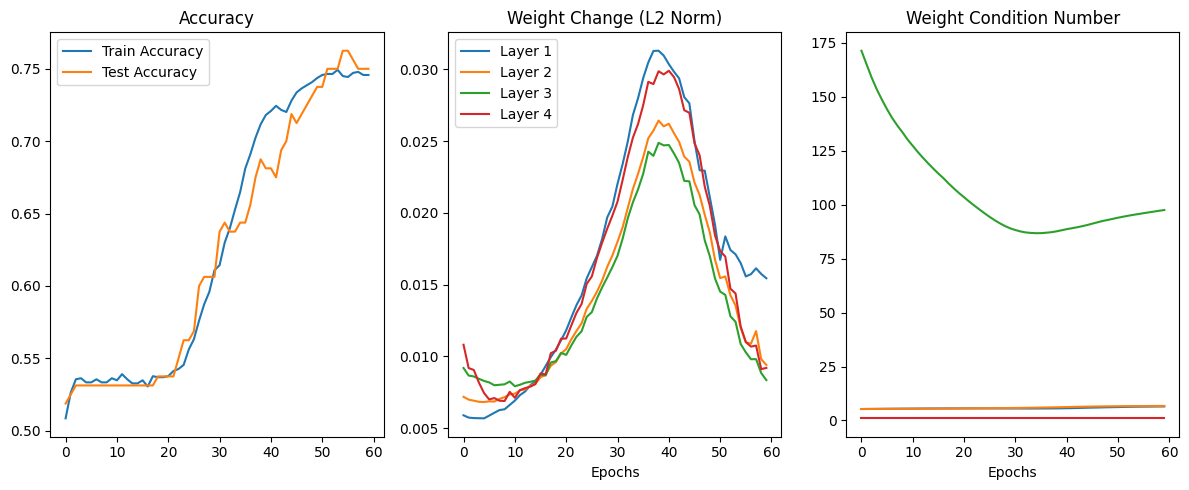

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

# accuracy
ax[0].plot(train_acc, label="Train Accuracy")
ax[0].plot(test_acc, label="Test Accuracy")
ax[0].set_title("Accuracy")
ax[0].legend()

# Weight change
ax[1].plot(weight_change)
ax[1].set_title("Weight Change (L2 Norm)")
ax[1].set_xlabel("Epochs")
ax[1].legend(["Layer 1", "Layer 2", "Layer 3", "Layer 4"])

# Weight condition number
ax[2].plot(weight_conds)
ax[2].set_title("Weight Condition Number")
ax[2].set_xlabel("Epochs")
plt.tight_layout()
plt.show()

# we can see that the accuracy increases drastically between epochs 30 and 50, where we have the largest changes in weights.
# the condition number are quite stable during the training, which means that the weights are not becoming singular, which is a good sign.
# in additon except layer 3, the rest have a small condition number which indicate they are quite spherical.
# Layer 3 has a much higher condition number, which means that the weights are becoming more singular, which could be a sign of overfitting.

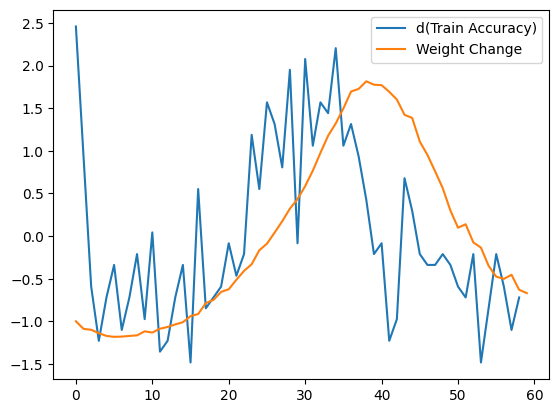

In [36]:
from scipy.stats import zscore

# check if there is a correlation between the change in accuracy and the change in weights. We will use the z-score to standardize the data 
# and make it easier to compare.
plt.plot(zscore(np.diff(train_acc)))
plt.plot(zscore(np.mean(weight_change, axis=1)))
plt.legend(["d(Train Accuracy)", "Weight Change"])